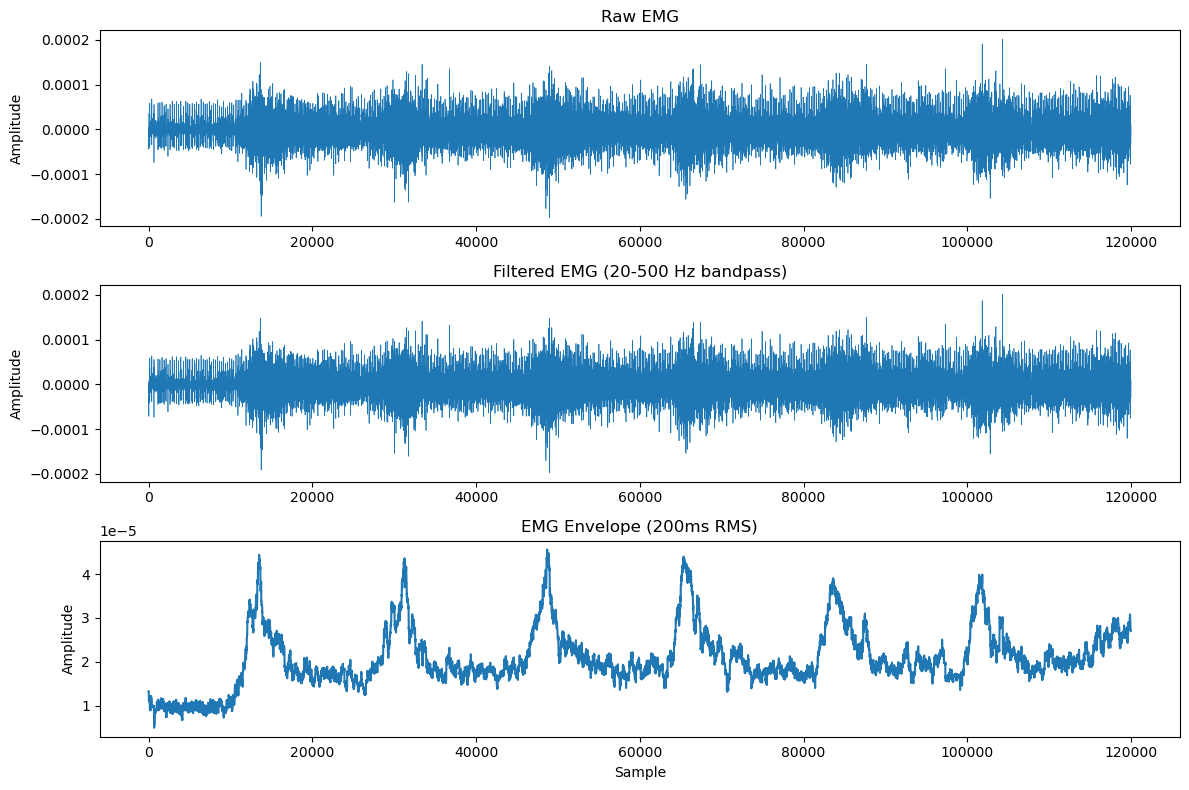

In [ ]:
from scipy.signal import butter, filtfilt
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

# Loading data
data = sio.loadmat('../data/S17_E1_A1.mat')
emg = data['emg']
labels = data['restimulus']

# Sampling rate Hz
fs = 2000

# Nyqvist frequency
nyq = fs / 2

def bandpass_filter(signal, lowcut = 20, highcut = 500, fs = 2000, order = 4):
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    
    return filtfilt(b, a, signal)

def get_envelope(signal, windowMs = 200):
    windowSamples = int(windowMs * fs / 1000)
    envelope = np.array([
        np.sqrt(np.mean(signal[i:i+windowSamples]**2))
        for i in range (len(signal) - windowSamples)
    ])

    return envelope

# Apply to channel 1
raw = emg[:, 0]
filtered = bandpass_filter(raw)
envelope = get_envelope(filtered)

# Plot all three
samples_to_plot = 60 * fs

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)

axes[0].plot(raw[:samples_to_plot], linewidth=0.5)
axes[0].set_title('Raw EMG')
axes[0].set_ylabel('Amplitude')

axes[1].plot(filtered[:samples_to_plot], linewidth=0.5)
axes[1].set_title('Filtered EMG (20-500 Hz bandpass)')
axes[1].set_ylabel('Amplitude')

axes[2].plot(envelope[:samples_to_plot])
axes[2].set_title('EMG Envelope (RMS)')
axes[2].set_ylabel('Amplitude')

axes[2].set_xlabel('Sample')
plt.tight_layout()
plt.show()
